# Импорты

In [3]:
from enum import Enum
from tokenizers import Tokenizer
from torch.utils.data.dataset import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from tokenizers.models import BPE, Unigram, WordLevel, WordPiece
from torch.utils.data import DataLoader

/home/misha/Desktop/knowledge_distillation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Инициализация токенизаторов

In [4]:
model_name_1 = "LiquidAI/LFM2.5-230M"
tokenizer_1 = Tokenizer.from_pretrained(model_name_1)
print(f'Длина словаря {model_name_1}: {tokenizer_1.get_vocab_size()}')
print(f'Модель токенизатора {model_name_1}: {tokenizer_1.model}')

Длина словаря LiquidAI/LFM2.5-230M: 64402
Модель токенизатора LiquidAI/LFM2.5-230M: BPE(dropout=None, unk_token=None, continuing_subword_prefix=None, end_of_word_suffix=None, fuse_unk=False, byte_fallback=False, ignore_merges=False, vocab={"<|pad|>":0, "<|startoftext|>":1, "<|endoftext|>":2, "<|fim_pre|>":3, "<|fim_mid|>":4, ...}, merges=[("Ċ", "Ċ"), ("Ċ", "ĊĊ"), ("ĊĊ", "Ċ"), ("Ċ", "ĊĊĊ"), ("ĊĊ", "ĊĊ"), ...])


In [5]:
model_name_2 = "xlnet/xlnet-base-cased"
tokenizer_2 = Tokenizer.from_pretrained(model_name_2)
print(f'Длина словаря {model_name_2}: {tokenizer_2.get_vocab_size()}')
print(f'Модель токенизатора {model_name_2}: {tokenizer_2.model}')

Длина словаря xlnet/xlnet-base-cased: 32000
Модель токенизатора xlnet/xlnet-base-cased: Unigram(unk_id=0, vocab=[("<unk>", 0), ("<s>", 0), ("</s>", 0), ("<cls>", 0), ("<sep>", 0), ...], byte_fallback=False)


# Инициализация моделей

In [6]:
tokenizer_model_1 = AutoTokenizer.from_pretrained(model_name_1)
model_1 = AutoModelForCausalLM.from_pretrained(model_name_1,
                                               torch_dtype="auto",
                                               device_map="auto")

Loading weights: 100%|██████████| 132/132 [00:00<00:00, 1723.28it/s]


In [7]:
tokenizer_model_2 = AutoTokenizer.from_pretrained(model_name_2)
model_2 = AutoModelForCausalLM.from_pretrained(model_name_2,
                                               torch_dtype="auto",
                                               device_map="auto")

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 1727.80it/s]


# Предобработка данных

In [8]:
class TokenizerModel(Enum):
    BPE = "BPE"
    WordPiece = "WordPiece"
    Unigram = "Unigram"

In [10]:
exact_match_dict = {}
model_1_exact_tokens = []
model_2_exact_tokens = []

non_exact_tokens = []

if isinstance(tokenizer_1.model, BPE):
    if isinstance(tokenizer_2.model, Unigram):
        vocab_1 = tokenizer_1.get_vocab()
        vocab_2 = tokenizer_2.get_vocab()
        for key in vocab_1.keys():
            key_candidate = key
            if key[0] == 'Ġ':
                key = key.replace('Ġ', '▁')
            if key in vocab_2.keys():
                exact_match_dict[vocab_1[key_candidate]] = vocab_2[key]
                model_1_exact_tokens.append(vocab_1[key_candidate])
                model_2_exact_tokens.append(vocab_2[key])
            else:
                non_exact_tokens.append(vocab_1[key_candidate])

exact_match_list = [(token_1, token_2) for token_1, token_2 in exact_match_dict.items()]

In [11]:
non_exact_model_1 = {}
non_exact_model_2 = {}
embedding_layer_1 = model_1.get_input_embeddings()
embedding_layer_2 = model_2.get_input_embeddings()

for token, idx in vocab_1.items():
    if idx not in model_1_exact_tokens:
        non_exact_model_1[idx] = embedding_layer_1.weight[idx]

for token, idx in vocab_2.items():
    if idx not in model_2_exact_tokens:
        non_exact_model_2[idx] = embedding_layer_2.weight[idx]

In [12]:
embedding_layer_1 = model_1.get_input_embeddings()
embedding_layer_2 = model_2.get_input_embeddings()
dataset = []

for token_1, token_2 in exact_match_list:
    embed_1 = embedding_layer_1.weight[token_1]
    # print(embed_1.shape)
    embed_2 = embedding_layer_2.weight[token_2]
    # print(embed_2.shape)
    dataset.append((embed_1, embed_2))


In [13]:
dataset_non_exact_1 = {}
dataset_non_exact_2 = {}

for token in non_exact_tokens:
    embed_1 = embedding_layer_1.weight[token]
    dataset_non_exact_1[token] = embed_1

# Построение пайплайна загрузки данных в модель

In [14]:
class Kind(Enum):
    train = "train"
    test = "test"

TRAIN_RATIO = 0.8

In [15]:
class ExactMatchDataset(Dataset):
    def __init__(self, dataset: list[tuple], train_ratio: float, kind: Kind):
        self.dataset = self._train_test_split(dataset=dataset, train_ratio=train_ratio, kind=kind)
    
    def _train_test_split(self, dataset: list[tuple], train_ratio: float, kind: str):
        upper_limit = int(len(dataset)*train_ratio)
        if kind == Kind.train:
            return dataset[:upper_limit]
        elif kind == Kind.test:
            return dataset[upper_limit:]
        else:
            raise ValueError("Выбран неправильный тип датасета: возможен только train или test")

    def __getitem__(self, idx):
        model_1_embed = self.dataset[idx][0] # input embed
        model_2_embed = self.dataset[idx][1] # output embed
        return model_1_embed, model_2_embed
    
    def __len__(self):
        return len(self.dataset)

In [16]:
train = ExactMatchDataset(dataset, TRAIN_RATIO, Kind.train)
valid = ExactMatchDataset(dataset, TRAIN_RATIO, Kind.test)

train_dataloader = DataLoader(train, batch_size=64, shuffle=True)
valid_dataloader = DataLoader(valid, batch_size=64, shuffle=True)

In [23]:
import torch.nn as nn

class EmbedProjector(nn.Module):
    def __init__(self, input_dim, num_hidden, output_dim):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=input_dim, out_features=num_hidden)
        self.norm_1 = nn.LayerNorm(num_hidden)
        self.activation_1 = nn.ReLU()
        self.layer_2 = nn.Linear(in_features=num_hidden, out_features=output_dim)
        self.skip = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)
        h = self.layer_1(x)
        h = self.norm_1(h)
        h = self.activation_1(h)
        h = self.layer_2(h)
        return h + residual

In [24]:
len(train[2][1])

768

In [284]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
model = EmbedProjector(input_dim=len(train[2][0]), num_hidden=512, output_dim=len(train[2][1])).to(device)

Using cuda device


In [25]:
from tqdm import tqdm

class ModelManager:
    def __init__(self, 
                 epoch_num: int, 
                 model: EmbedProjector, 
                 train_dataloader: DataLoader, 
                 val_dataloader: DataLoader,
                 device: str):
        self.epoch_num = epoch_num
        self.model = model
        self.model_dtype = self._get_model_dtype(model=model)
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader
        self.device = device
        self.optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

    def _get_model_dtype(self, model):
        return next(model.parameters()).dtype
    
    def criterion(self, y_predict, y):
        
        cosine_loss = nn.CosineEmbeddingLoss()
        target = torch.ones(
            y_predict.shape[0],
            device=y_predict.device,
            dtype=y_predict.dtype,
        )
        return cosine_loss(y_predict, y, target)

    def train_and_val_loop(self):
        average_train_loss_arr = {}
        average_val_loss_arr = {}
        average_val_loss_list = {}
        cosine_metric = nn.CosineSimilarity(dim=-1)
        cosine_arr = []
        for idx, epoch in enumerate(range(self.epoch_num)):
            self.model.train()
            total_loss = 0
            cosine_similarity = 0
            train_tqdm = tqdm(self.train_dataloader)
            for x_train, y_train in train_tqdm:
                x_train = x_train.to(device=self.device,
                                     dtype=self.model_dtype)
                y_train = y_train.to(device=self.device,
                                     dtype=self.model_dtype)
                self.optimizer.zero_grad()
                predict = self.model(x_train)
                loss = self.criterion(y_predict=predict, y=y_train)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()*x_train.size(0)

            mean_loss = total_loss/len(self.train_dataloader.dataset)
            average_train_loss_arr[epoch] = mean_loss
            print(f'Эпоха = {epoch+1}\nСредний train_loss = {mean_loss}')

            self.model.eval()
            with torch.inference_mode():
                val_tqdm = tqdm(self.val_dataloader)
                total_loss = 0
                for x_val, y_val in val_tqdm:
                    x_val = x_val.to(device=self.device,
                                    dtype=self.model_dtype)
                    y_val = y_val.to(device=self.device,
                                    dtype=self.model_dtype)
                    predict = self.model(x_val)
                    loss = self.criterion(y_predict=predict, y=y_val)
                    batch_cosine_similarity = cosine_metric(predict, y_val)
                    cosine_similarity += batch_cosine_similarity.sum().item()
                    total_loss += loss.item()*x_val.size(0)
            
            mean_cos = cosine_similarity/len(self.val_dataloader.dataset)
            cosine_arr.append(mean_cos)
            mean_loss = total_loss/len(self.val_dataloader.dataset)
            average_val_loss_arr[epoch] = mean_loss

            print(f'Средний val_loss = {mean_loss}')
            print(f'Среднее косинусное сходство = {mean_cos}')
            if idx != 0:
                if average_val_loss_arr[idx] < average_val_loss_arr[idx-1]:
                    print(f'Качество модели улучшилось на {average_val_loss_arr[idx-1]-average_val_loss_arr[idx]} по лоссу, сохраняем модель')
                    torch.save(self.model.state_dict(), 'embedder_model.pth')
                else:
                    print('Модель не оверперформит, заканчиваю обучение...')
                    break
            print('###########################')

            
            
        
        return average_train_loss_arr, average_val_loss_arr

In [286]:
model_manager = ModelManager(epoch_num=25,
                             model=model, 
                             train_dataloader=train_dataloader, 
                             val_dataloader=valid_dataloader,
                             device='cuda')

average_train_loss_arr, average_val_loss_arr = model_manager.train_and_val_loop()

100%|██████████| 255/255 [00:37<00:00,  6.83it/s]


Эпоха = 1
Средний train_loss = 0.5142509582154062


100%|██████████| 64/64 [00:00<00:00, 1827.14it/s]


Средний val_loss = 0.4027216982084561
Среднее косинусное сходство = 0.5972783031870437
###########################


100%|██████████| 255/255 [00:37<00:00,  6.84it/s]


...

Средний val_loss = 0.3345742542520403
Среднее косинусное сходство = 0.6654257525354953
Качество модели улучшилось на 0.0006117105747034945 по лоссу, сохраняем модель
###########################


100%|██████████| 255/255 [00:36<00:00,  6.91it/s]


Эпоха = 21
Средний train_loss = 0.2803876582428759


100%|██████████| 64/64 [00:00<00:00, 2016.87it/s]

Средний val_loss = 0.33490501375255644
Среднее косинусное сходство = 0.6650949891041996
Модель не оверперформит, заканчиваю обучение...


In [27]:
model_new = EmbedProjector(input_dim=len(train[2][0]), num_hidden=512, output_dim=len(train[2][1])).to(device)
model_new.load_state_dict(
    torch.load("embedder_model.pth", map_location="cuda")
)
model_new.eval()

EmbedProjector(
  (layer_1): Linear(in_features=1024, out_features=512, bias=True)
  (norm_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
  (activation_1): ReLU()
  (layer_2): Linear(in_features=512, out_features=768, bias=True)
  (skip): Linear(in_features=1024, out_features=768, bias=True)
)

In [28]:
vocab_1_reverse = {value: key for key, value in vocab_1.items()}
vocab_2_reverse = {value: key for key, value in vocab_2.items()}

In [32]:
cosine = nn.CosineSimilarity(dim=-1, eps=1e-6)


for token_1, embed in non_exact_model_1.items():
    measured_cos_dict = {}
    embed = embed.to(device='cuda',
                     dtype=next(model_new.parameters()).dtype)
    converted_embed = model_new(embed)
    for token_2, embed2 in non_exact_model_2.items():
        measured_cos = cosine(embed2, converted_embed)
        measured_cos_dict[measured_cos] = token_2


    print(f'Для такого токена {vocab_1_reverse[token_1]} наиболе близким оказался {vocab_2_reverse[measured_cos_dict[max(measured_cos_dict.keys())]]}')
    print(f'Замеренное косинусное сходство — {max(measured_cos_dict.keys())}')
    print('####################')

Для такого токена Ġfaj наиболе близким оказался ▁2011,
Замеренное косинусное сходство — 0.601681113243103
####################
Для такого токена ĠÑģÑĤÐ°Ð½Ð¾Ð² наиболе близким оказался ▁1975,
Замеренное косинусное сходство — 0.5812206864356995
####################


KeyboardInterrupt: 

In [2]:
import gc
import torch

del new_model

# Если использовались при обучении:
# del optimizer
# del scheduler

# Если остались результаты инференса:
# del outputs
# del logits
# del generated_ids
# del loss

gc.collect()
torch.cuda.empty_cache()

NameError: name 'new_model' is not defined

In [36]:
import torch
import torch.nn.functional as F

def running_topk_mean(query, keys, k=10, batch_size=2048):
    """
    Для каждой строки query считает среднее по top-k косинусных сходств
    с keys, не храня полную матрицу сходств.
    query: [N_q, D] (нормализованные)
    keys:  [N_k, D] (нормализованные)
    returns: [N_q] — средняя близость к top-k соседям в keys
    """
    N_q = query.shape[0]
    result = torch.empty(N_q, device=query.device, dtype=query.dtype)

    for start in range(0, N_q, batch_size):
        end = min(start + batch_size, N_q)
        q_batch = query[start:end]                # [B, D]
        sims = q_batch @ keys.T                    # [B, N_k] — временная, но маленькая по B
        topk_vals = sims.topk(k, dim=1).values      # [B, k]
        result[start:end] = topk_vals.mean(dim=1)
        del sims, topk_vals
        torch.cuda.empty_cache()

    return result


def csls_best_match(src_embeds, tgt_embeds, k=10, batch_size=2048):
    src = F.normalize(src_embeds, dim=-1)
    tgt = F.normalize(tgt_embeds, dim=-1)

    # r_S(y): близость каждого tgt-токена к его top-k соседям среди src
    r_tgt = running_topk_mean(tgt, src, k=k, batch_size=batch_size)  # [N_tgt]

    # r_T(x): близость каждого src-токена к его top-k соседям среди tgt
    r_src = running_topk_mean(src, tgt, k=k, batch_size=batch_size)  # [N_src]

    best_idx = torch.empty(src.shape[0], dtype=torch.long, device=src.device)
    best_score = torch.empty(src.shape[0], device=src.device, dtype=src.dtype)

    for start in range(0, src.shape[0], batch_size):
        end = min(start + batch_size, src.shape[0])
        s_batch = src[start:end]                    # [B, D]
        sims = s_batch @ tgt.T                       # [B, N_tgt]
        csls_batch = 2 * sims - r_src[start:end].unsqueeze(1) - r_tgt.unsqueeze(0)
        vals, idx = csls_batch.max(dim=1)
        best_idx[start:end] = idx
        best_score[start:end] = vals
        del sims, csls_batch
        torch.cuda.empty_cache()

    return best_idx, best_score

In [38]:
best_idx, best_score = csls_best_match(converted, embeds_2, k=10, batch_size=1024)

for i, t1 in enumerate(tokens_1):
    t2 = tokens_2[best_idx[i].item()]
    print(f'{vocab_1_reverse[t1]} -> {vocab_2_reverse[t2]}, CSLS={best_score[i].item():.4f}')

Ġfaj -> ▁saute, CSLS=-0.2055
ĠÑģÑĤÐ°Ð½Ð¾Ð² -> ▁Become, CSLS=-0.0714
gebiet -> district, CSLS=-0.1713
-core -> ▁flagship, CSLS=-0.1377
ificar -> ficial, CSLS=-0.1505
'Union -> ▁Confederacy, CSLS=-0.1105
loor -> floor, CSLS=0.0570
Ġrecombination -> ▁diversification, CSLS=-0.0221
434 -> 2,600, CSLS=-0.0090
Ġrepre -> ▁chastise, CSLS=-0.0576
ĠSein -> ▁Lieb, CSLS=-0.1278
[: -> nowiki, CSLS=-0.2233
Ð°ÑĤÑĮÑģÑı -> yourself, CSLS=-0.2829
ĠÑĢÐ¾Ð´Ð¸ -> ▁2011,, CSLS=-0.1539
orgen -> uhl, CSLS=-0.1794
ĠUri -> ▁Aidan, CSLS=-0.0967
Ð½Ð°Ñģ -> ▁21,, CSLS=-0.1614
Ġcultiv -> ▁nurture, CSLS=0.0226
Ð»Ð°Ð´Ñĥ -> ▁2015,, CSLS=-0.1156
Ġdegraded -> ▁deteriorated, CSLS=0.1941
ĠCosm -> ▁Quar, CSLS=-0.1586
ĠenergÃŃa -> energize, CSLS=-0.0808
aciones -> tions, CSLS=-0.0791
Ø·ÙĤØ© -> district, CSLS=-0.1799
ĠThem -> ▁Anyway, CSLS=-0.0812
.sub -> ▁Subscribe, CSLS=-0.2485
Ġbesten -> ▁toughest, CSLS=-0.0209
Ġprescript -> ▁prescribing, CSLS=0.0150
ÙħÙĦ -> MOV, CSLS=-0.1405
Ġchemically -> ▁environmentally, CSLS=0.0173
Ð¾Ð²

In [ ]:
predicted_embed = 

<function matplotlib.pyplot.show(close=None, block=None)>

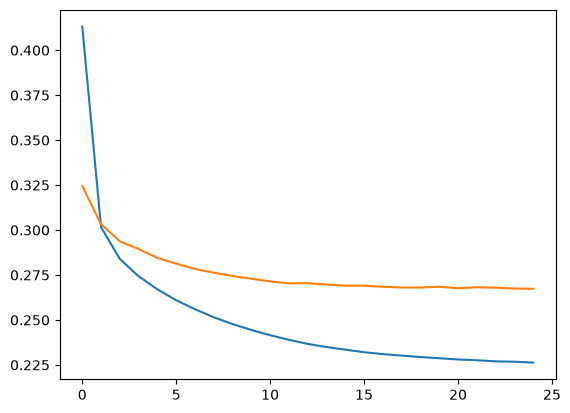

In [21]:
from matplotlib.pylab import plt

fig, ax = plt.subplots()

ax.plot(average_train_loss_arr.keys(), average_train_loss_arr.values())
ax.plot(average_val_loss_arr.keys(), average_val_loss_arr.values())
plt.show

In [22]:
# evaluate on the validation set
val_loss = 0
model.eval()
with torch.no_grad():
    for x_val, y_val in valid_dataloader:
        x_val = x_val.to(device=device,
                             dtype=model_dtype)
        y_val = y_val.to(device=device,
                             dtype=model_dtype)

        predict = model(x_val)
        loss = compute_loss(alpha=0.2, beta=0.8, y_predict=predict, y=y_train)

# Calculate the validation accuracy and validation loss
val_accuracy = 100 * correct / total
val_loss /= len(valid_dataloader.dataset)

NameError: name 'model_dtype' is not defined